## Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys

from pathlib import Path
from scipy.stats import iqr

from src.conformal.pipeline import run_mondrian_regression

## Load the data

In [54]:
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

print("cwd:", Path.cwd())
print("PROJECT_ROOT:", PROJECT_ROOT)

RESULTS_DIR = PROJECT_ROOT / "data" / "results"

file_path = RESULTS_DIR / "SimpleCNN_GN_v1_N5000_seed13_bestval0.5850_predictions_embeddings.npz"

print("RESULTS_DIR exists:", RESULTS_DIR.exists())
print("file_path:", file_path)
print("file exists:", file_path.exists())

data = np.load(file_path, allow_pickle=True)
print(data.files)

pred_cal = data["pred_cal"]
y_cal = data["y_cal"]
pred_test = data["pred_test"]
y_test = data["y_test"]

emb_cal = data["emb_cal"]
emb_test = data["emb_test"]

y_mean = data["y_mean"]
y_std = data["y_std"]

label_names = ["chirp_mass", "total_mass", "chi_eff"]

print("pred_cal:", pred_cal.shape)
print("y_cal:", y_cal.shape)
print("pred_test:", pred_test.shape)
print("y_test:", y_test.shape)
print("emb_cal:", emb_cal.shape)
print("emb_test:", emb_test.shape)
print("y_mean:", y_mean)
print("y_std:", y_std)

cwd: /home/victor/gw/cbc_pe/notebooks
PROJECT_ROOT: /home/victor/gw/cbc_pe
RESULTS_DIR exists: True
file_path: /home/victor/gw/cbc_pe/data/results/SimpleCNN_GN_v1_N5000_seed13_bestval0.5850_predictions_embeddings.npz
file exists: True
['pred_cal', 'emb_cal', 'y_cal', 'pred_test', 'emb_test', 'y_test', 'y_mean', 'y_std', 'checkpoint_file']
pred_cal: (500, 3)
y_cal: (500, 3)
pred_test: (500, 3)
y_test: (500, 3)
emb_cal: (500, 32)
emb_test: (500, 32)
y_mean: [3.7617809e+01 9.5261360e+01 1.5580951e-02]
y_std: [16.548046   34.859104    0.44490194]


In [55]:
assert pred_cal.ndim == 2
assert pred_test.ndim == 2
assert y_cal.ndim == 2
assert y_test.ndim == 2

assert pred_cal.shape == y_cal.shape
assert pred_test.shape == y_test.shape
assert pred_cal.shape[1] == len(label_names)
assert pred_test.shape[1] == len(label_names)

assert emb_cal.ndim == 2
assert emb_test.ndim == 2
assert emb_cal.shape[0] == pred_cal.shape[0]
assert emb_test.shape[0] == pred_test.shape[0]

assert y_mean.shape[0] == len(label_names)
assert y_std.shape[0] == len(label_names)
assert np.all(y_std > 0)

print("All sanity checks passed.")

All sanity checks passed.


## Compute the metrics for Mondrian

In [56]:
confidence_level = 0.90

n_bins_grid = [4, 6, 8, 12, 16, 24]
taxonomy_modes = ["prediction", "difficulty"]
interval_modes = ["symmetric", "asymmetric"]

rows = []
all_results = {}

for taxonomy_mode in taxonomy_modes:
    for interval_mode in interval_modes:
        for n_bins in n_bins_grid:

            kwargs = dict(
                pred_cal=pred_cal,
                pred_test=pred_test,
                y_cal=y_cal,
                y_test=y_test,
                n_bins=n_bins,
                confidence_level=confidence_level,
                apply_jitter=True,
                interval_mode=interval_mode,
                taxonomy_mode=taxonomy_mode,
            )

            if taxonomy_mode == "difficulty":
                kwargs.update(
                    cal_embedding=emb_cal,
                    target_embedding=emb_test,
                    n_neighbors=5,
                )

            result = run_mondrian_regression(**kwargs)
            all_results[(taxonomy_mode, interval_mode, n_bins)] = result

            metrics = result.metrics
            widths_std = result.upper - result.lower

            for j, label in enumerate(label_names):
                row = {
                    "taxonomy_mode": taxonomy_mode,
                    "interval_mode": interval_mode,
                    "n_bins": n_bins,
                    "label": label,
                    "label_index": j,

                    "n_samples": int(metrics["n_samples_per_label"][j]),
                    "covered_count": int(metrics["covered_count_global"][j]),

                    "global_coverage": metrics["global_coverage"][j],
                    "miscoverage": metrics["miscoverage"][j],
                    "global_coverage_gap": metrics["global_coverage_gap"][j],
                    "global_undercoverage_pvalue": metrics["global_undercoverage_pvalue"][j],

                    "global_mean_width_std": metrics["global_mean_width"][j],
                    "global_median_width_std": metrics["global_median_width"][j],

                    "global_mean_width_phys": np.mean(widths_std[:, j]) * y_std[j],
                    "global_median_width_phys": np.median(widths_std[:, j]) * y_std[j],
                    "global_iqr_width_phys": iqr(widths_std[:, j]) * y_std[j],

                    "min_coverage_per_bin": metrics["min_coverage_per_label"][j],
                    "max_undercoverage_gap": metrics["max_undercoverage_gap"][j],
                    "min_count_per_bin": int(np.nanmin(metrics["counts_per_bin"][:, j])),
                    "max_count_per_bin": int(np.nanmax(metrics["counts_per_bin"][:, j])),
                    "n_bad_bins_p005": int(np.nansum(metrics["bin_undercoverage_pvalue"][:, j] < 0.05)),
                }

                global_tol = metrics["global_tolerance_normal"]

                for k in [1, 2, 3]:
                    low = global_tol[f"{k}sigma_low"][j]
                    high = global_tol[f"{k}sigma_high"][j]
                    width = global_tol[f"{k}sigma_width"][j]

                    row[f"global_tol_{k}sigma_low"] = low
                    row[f"global_tol_{k}sigma_high"] = high
                    row[f"global_tol_{k}sigma_width"] = width
                    row[f"global_within_{k}sigma"] = (
                        low <= row["global_coverage"] <= high
                    )

                rows.append(row)

summary_df = pd.DataFrame(rows)
summary_df.head()

,taxonomy_mode,interval_mode,n_bins,label,label_index,n_samples,covered_count,global_coverage,miscoverage,global_coverage_gap,...,global_tol_1sigma_width,global_within_1sigma,global_tol_2sigma_low,global_tol_2sigma_high,global_tol_2sigma_width,global_within_2sigma,global_tol_3sigma_low,global_tol_3sigma_high,global_tol_3sigma_width,global_within_3sigma
0,prediction,symmetric,4,chirp_mass,0,500,463,0.926,0.074,0.026,...,0.013416,False,0.873167,0.926833,0.026833,True,0.859751,0.940249,0.040249,True
1,prediction,symmetric,4,total_mass,1,500,467,0.934,0.066,0.034,...,0.013416,False,0.873167,0.926833,0.026833,False,0.859751,0.940249,0.040249,True
2,prediction,symmetric,4,chi_eff,2,500,462,0.924,0.076,0.024,...,0.013416,False,0.873167,0.926833,0.026833,True,0.859751,0.940249,0.040249,True
3,prediction,symmetric,6,chirp_mass,0,500,466,0.932,0.068,0.032,...,0.013416,False,0.873167,0.926833,0.026833,False,0.859751,0.940249,0.040249,True
4,prediction,symmetric,6,total_mass,1,500,468,0.936,0.064,0.036,...,0.013416,False,0.873167,0.926833,0.026833,False,0.859751,0.940249,0.040249,True


## Ranking configurations

In [58]:
valid_df = summary_df[
    (summary_df["global_within_2sigma"]) &
    (summary_df["max_undercoverage_gap"] <= 0.08) &
    (summary_df["min_count_per_bin"] >= 20)
].copy()

ranking_df = valid_df.sort_values(
    ["label", "global_median_width_phys"],
    ascending=[True, True],
)

ranking_df[
    [
        "label",
        "taxonomy_mode",
        "interval_mode",
        "n_bins",
        "global_coverage",
        "global_within_1sigma",
        "global_within_2sigma",
        "global_undercoverage_pvalue",
        "min_coverage_per_bin",
        "max_undercoverage_gap",
        "n_bad_bins_p005",
        "global_median_width_phys",
        "global_iqr_width_phys",
        "min_count_per_bin",
    ]
]

,label,taxonomy_mode,interval_mode,n_bins,global_coverage,global_within_1sigma,global_within_2sigma,global_undercoverage_pvalue,min_coverage_per_bin,max_undercoverage_gap,n_bad_bins_p005,global_median_width_phys,global_iqr_width_phys,min_count_per_bin
23,chi_eff,prediction,asymmetric,6,0.902,True,True,0.581041,0.822785,0.077215,1,1.408138,0.123162,71
2,chi_eff,prediction,symmetric,4,0.924,False,True,0.972570,0.881356,0.018644,0,1.418898,0.033217,115
26,chi_eff,prediction,asymmetric,8,0.918,False,True,0.924911,0.833333,0.066667,0,1.420572,0.084412,44
59,chi_eff,difficulty,asymmetric,6,0.908,True,True,0.745311,0.823529,0.076471,1,1.449025,0.201555,69
20,chi_eff,prediction,asymmetric,4,0.926,False,True,0.981367,0.899160,0.000840,0,1.463609,0.042004,115
5,chi_eff,prediction,symmetric,6,0.926,False,True,0.981367,0.885057,0.014943,0,1.472724,0.134861,71
41,chi_eff,difficulty,symmetric,6,0.926,False,True,0.981367,0.888889,0.011111,0,1.480251,0.185425,69
60,chirp_mass,difficulty,asymmetric,8,0.918,False,True,0.924911,0.873016,0.026984,0,39.103329,8.578951,39
42,chirp_mass,difficulty,symmetric,8,0.910,True,True,0.792038,0.841270,0.058730,0,39.118557,8.055987,39
21,chirp_mass,prediction,asymmetric,6,0.922,False,True,0.960660,0.886076,0.013924,0,42.372427,7.002549,71


## Check a configuration 

In [57]:
key = ("difficulty", "symmetric", 12)
result = all_results[key]
metrics = result.metrics

label_idx = 0
label = label_names[label_idx]

print("Configuration:", key)
print("Label:", label)
print("Counts per bin:")
print(metrics["counts_per_bin"][:, label_idx])

print("\nCoverage per bin:")
print(np.round(metrics["coverage_per_bin"][:, label_idx], 3))

print("\nCovered count per bin:")
print(metrics["covered_count_per_bin"][:, label_idx])

print("\nBin undercoverage p-values:")
print(np.round(metrics["bin_undercoverage_pvalue"][:, label_idx], 4))

Configuration: ('difficulty', 'symmetric', 12)
Label: chirp_mass
Counts per bin:
[63 28 35 45 35 36 26 38 31 46 52 65]

Coverage per bin:
[0.889 0.893 0.971 0.933 0.943 0.944 0.962 0.974 0.935 0.978 0.942 0.923]

Covered count per bin:
[56 25 34 42 33 34 25 37 29 45 49 60]

Bin undercoverage p-values:
[0.4442 0.5406 0.975  0.841  0.8776 0.8874 0.9354 0.9818 0.8304 0.9921
 0.9034 0.7909]


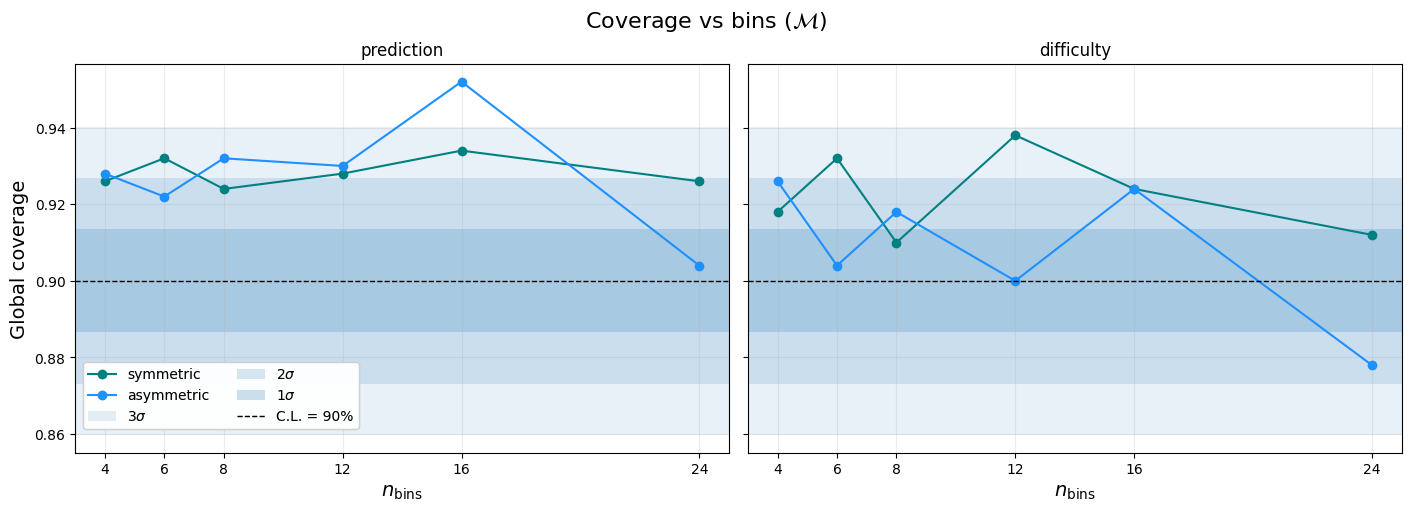

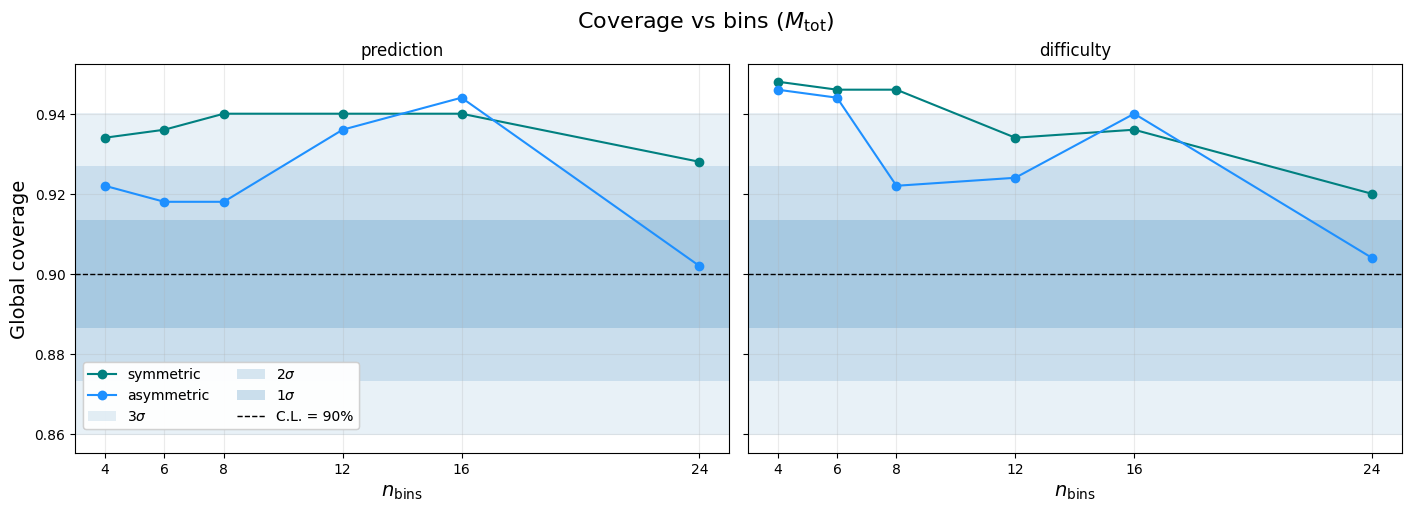

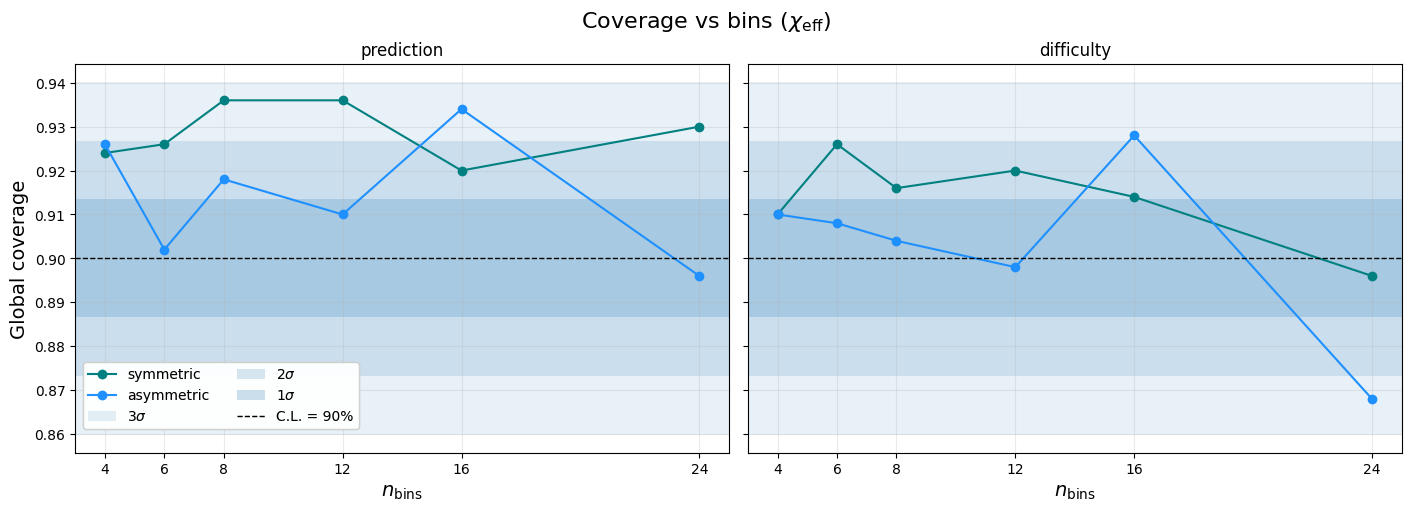

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plot_labels = {
    "chirp_mass": r"$\mathcal{M}$",
    "total_mass": r"$M_{\mathrm{tot}}$",
    "chi_eff": r"$\chi_{\mathrm{eff}}$",
}

plot_colors = {
    "symmetric": "teal",
    "asymmetric": "dodgerblue", 
}

for label in label_names:
    df_label = summary_df[summary_df["label"] == label]

    fig, axes = plt.subplots(
        1,
        len(taxonomy_modes),
        figsize=(14, 5),
        sharey=True,
        constrained_layout=True,
    )

    # Por si taxonomy_modes tuviera longitud 1
    axes = np.atleast_1d(axes)

    for ax, taxonomy_mode in zip(axes, taxonomy_modes):
        df_tax = df_label[df_label["taxonomy_mode"] == taxonomy_mode]

        for interval_mode in interval_modes:
            df_mode = (
                df_tax[df_tax["interval_mode"] == interval_mode]
                .sort_values("n_bins")
            )

            ax.plot(
                df_mode["n_bins"],
                df_mode["global_coverage"],
                marker="o",
                label=interval_mode,
                color=plot_colors[interval_mode],
            )

        # Tolerancias globales: para este label, n debería ser constante
        low_1 = df_tax["global_tol_1sigma_low"].iloc[0]
        high_1 = df_tax["global_tol_1sigma_high"].iloc[0]
        low_2 = df_tax["global_tol_2sigma_low"].iloc[0]
        high_2 = df_tax["global_tol_2sigma_high"].iloc[0]
        low_3 = df_tax["global_tol_3sigma_low"].iloc[0]
        high_3 = df_tax["global_tol_3sigma_high"].iloc[0]

        ax.axhspan(low_3, high_3, alpha=0.10, label=r"$3\sigma$", )
        ax.axhspan(low_2, high_2, alpha=0.15, label=r"$2\sigma$")
        ax.axhspan(low_1, high_1, alpha=0.20, label=r"$1\sigma$")
        ax.axhline(
            confidence_level,
            color="black",
            linestyle="--",
            linewidth=1,
            label=rf"C.L. = {int(confidence_level*100)}%",
        )

        ax.set_xticks(sorted(df_tax["n_bins"].unique()))
        ax.set_xlabel(r"$n_{\mathrm{bins}}$", fontsize=14)
        ax.set_title(taxonomy_mode)
        ax.grid(alpha=0.25)

        handles, labels_legend = ax.get_legend_handles_labels()
        fig.legend(
            handles,
            labels_legend,
            loc="upper left",
            bbox_to_anchor=(0.05, 0.30),
            ncol=2,
        )

    axes[0].set_ylabel("Global coverage", fontsize=14)

    fig.suptitle(f"Coverage vs bins ({plot_labels[label]})", fontsize=16)

    

    plt.show()

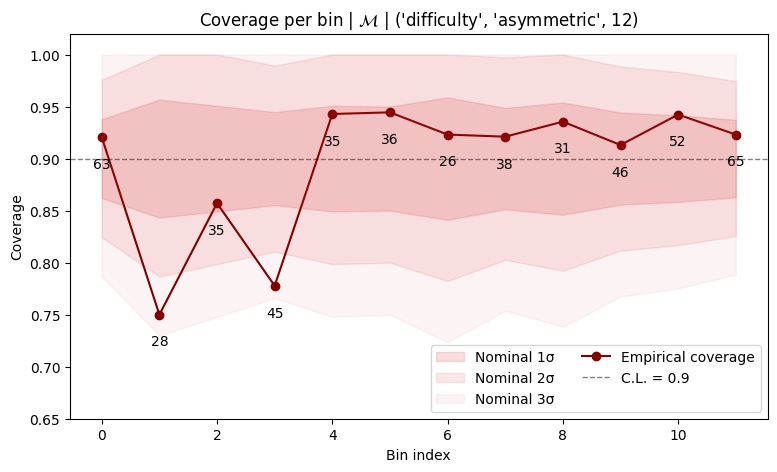

In [169]:
key = ("difficulty", "asymmetric", 12)
result = all_results[key]
metrics = result.metrics

label_idx = 0
label = label_names[label_idx]

coverage_per_bin = metrics["coverage_per_bin"][:, label_idx]
counts_per_bin = metrics["counts_per_bin"][:, label_idx]
bin_tol = metrics["bin_tolerance_normal"]

x = np.arange(len(coverage_per_bin))

low_1 = bin_tol["1sigma_low"][:, label_idx]
low_2 = bin_tol["2sigma_low"][:, label_idx]
low_3 = bin_tol["3sigma_low"][:, label_idx]
high_1 = bin_tol["1sigma_high"][:, label_idx]
high_2 = bin_tol["2sigma_high"][:, label_idx] 

high_3 = bin_tol["3sigma_high"][:, label_idx]

band_color = "tab:red"

plt.figure(figsize=(9, 5))


plt.fill_between(x, low_1, high_1, color=band_color, alpha=0.15, label="Nominal 1σ", zorder=3)
plt.fill_between(x, low_2, high_2, color=band_color, alpha=0.10, label="Nominal 2σ", zorder=2)
plt.fill_between(x, low_3, high_3, color=band_color, alpha=0.05, label="Nominal 3σ", zorder=1)
plt.plot(x, coverage_per_bin, marker="o", color="maroon", label="Empirical coverage" )
plt.axhline(confidence_level, linestyle="--", alpha=0.5, linewidth=1.0, color="black", label=rf"C.L. = {confidence_level}")

for i, n in enumerate(counts_per_bin):
    plt.text(i, coverage_per_bin[i] - 0.03, str(n), ha="center", fontsize=10, color="k")

plt.xlabel("Bin index")
plt.ylabel("Coverage")
plt.title(f"Coverage per bin | {plot_labels[label]} | {key}")
plt.ylim(0.65, 1.02)
plt.legend(ncols=2, loc="lower right")
plt.show()